# Lab 03: Neural Information Processing
**ITAI 4374 — Module 03**



## Setup — Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

---
## Part 1: Biological Neuron Model

This class simulates an **integrate-and-fire** neuron.  
Key concepts modelled: resting potential, threshold, all-or-none action potential, refractory period, and passive decay.

In [ ]:
class BiologicalNeuron:
    """Simulates basic biological neuron characteristics using a
    simplified integrate-and-fire model."""

    def __init__(self):
        self.resting_potential  = -70   # mV — stable voltage at rest
        self.threshold          = -55   # mV — voltage needed to trigger AP
        self.peak_potential     =  40   # mV — action potential peak
        self.refractory_period  =   5   # time steps — post-AP recovery window
        self.decay_rate         =   0.9 # membrane potential decay factor

    def simulate_response(self, input_current, time_steps=150, label=""):
        """
        Simulates membrane potential over time given a constant input current.

        Parameters
        ----------
        input_current : float  — injected current (mV added per step)
        time_steps    : int    — number of simulation steps
        label         : str    — optional plot title suffix
        """
        membrane_potential = self.resting_potential
        membrane_potentials = []
        refractory_counter  = 0

        for t in range(time_steps):
            if refractory_counter > 0:
                # During refractory period: potential snaps back to resting
                membrane_potential = self.resting_potential
                refractory_counter -= 1
            else:
                # Integrate input current
                membrane_potential += input_current

                # All-or-none: fire if threshold crossed
                if membrane_potential >= self.threshold:
                    membrane_potential = self.peak_potential
                    refractory_counter = self.refractory_period
                else:
                    # Passive decay toward resting potential
                    membrane_potential = (
                        membrane_potential * self.decay_rate
                        + self.resting_potential * (1 - self.decay_rate)
                    )

            # Clamp to realistic physiological range
            membrane_potential = max(-90, min(50, membrane_potential))
            membrane_potentials.append(membrane_potential)

        # ── Plot ──────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(membrane_potentials, color='steelblue', linewidth=1.5)
        ax.axhline(self.resting_potential, color='gray',   linestyle='--',
                   linewidth=0.8, label=f'Resting ({self.resting_potential} mV)')
        ax.axhline(self.threshold,         color='orange', linestyle='--',
                   linewidth=0.8, label=f'Threshold ({self.threshold} mV)')
        ax.set_xlabel("Time (steps)")
        ax.set_ylabel("Membrane Potential (mV)")
        ax.set_title(f"Biological Neuron Response — Input current = {input_current}"
                     + (f" ({label})" if label else ""))
        ax.legend(loc='upper right', fontsize=9)
        ax.set_ylim(-95, 55)
        plt.tight_layout()
        plt.show()

        return membrane_potentials

### 1a — Sub-threshold input  
Input current is too weak to reach threshold → **no action potential**.

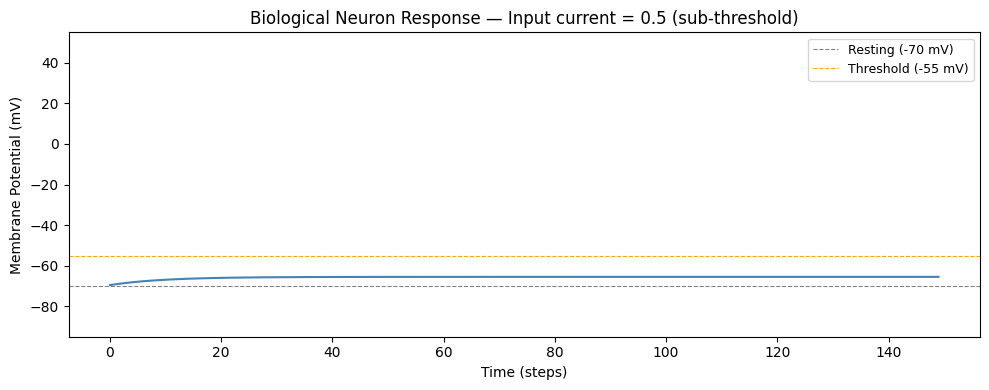

[-69.55,
 -69.145,
 -68.78049999999999,
 -68.45244999999998,
 -68.15720499999999,
 -67.89148449999999,
 -67.65233604999999,
 -67.437102445,
 -67.2433922005,
 -67.06905298045,
 -66.91214768240499,
 -66.77093291416449,
 -66.64383962274803,
 -66.52945566047323,
 -66.42651009442591,
 -66.33385908498332,
 -66.25047317648499,
 -66.17542585883649,
 -66.10788327295283,
 -66.04709494565755,
 -65.99238545109179,
 -65.94314690598262,
 -65.89883221538435,
 -65.85894899384591,
 -65.82305409446133,
 -65.79074868501519,
 -65.76167381651366,
 -65.7355064348623,
 -65.71195579137607,
 -65.69076021223846,
 -65.6716841910146,
 -65.65451577191314,
 -65.63906419472183,
 -65.62515777524965,
 -65.61264199772468,
 -65.60137779795221,
 -65.59124001815698,
 -65.58211601634127,
 -65.57390441470714,
 -65.56651397323643,
 -65.55986257591277,
 -65.5538763183215,
 -65.54848868648935,
 -65.54363981784041,
 -65.53927583605638,
 -65.53534825245073,
 -65.53181342720566,
 -65.5286320844851,
 -65.52576887603658,
 -65.52319

In [ ]:
neuron = BiologicalNeuron()
neuron.simulate_response(0.5, label="sub-threshold")

### 1b — Near-threshold input  
Current just barely reaches threshold → **sparse firing**.

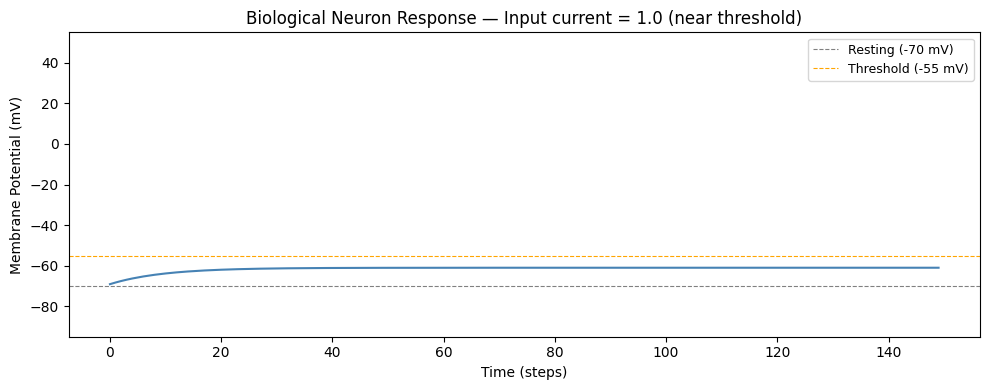

[-69.1,
 -68.28999999999999,
 -67.56099999999999,
 -66.9049,
 -66.31441,
 -65.782969,
 -65.30467209999999,
 -64.87420488999999,
 -64.48678440099998,
 -64.13810596089998,
 -63.824295364809984,
 -63.54186582832899,
 -63.287679245496086,
 -63.05891132094648,
 -62.85302018885183,
 -62.66771816996665,
 -62.50094635296998,
 -62.35085171767299,
 -62.21576654590569,
 -62.09418989131512,
 -61.984770902183605,
 -61.886293811965245,
 -61.79766443076872,
 -61.71789798769185,
 -61.64610818892267,
 -61.581497370030405,
 -61.52334763302736,
 -61.471012869724625,
 -61.42391158275216,
 -61.381520424476946,
 -61.343368382029254,
 -61.30903154382633,
 -61.278128389443694,
 -61.25031555049932,
 -61.225283995449395,
 -61.202755595904456,
 -61.18248003631401,
 -61.16423203268261,
 -61.14780882941435,
 -61.133027946472914,
 -61.11972515182563,
 -61.10775263664306,
 -61.096977372978756,
 -61.08727963568088,
 -61.078551672112795,
 -61.07069650490152,
 -61.06362685441137,
 -61.057264168970235,
 -61.051537752073

In [ ]:
neuron.simulate_response(1.0, label="near threshold")

### 1c — Strong input  
High current → **high-frequency firing** (many action potentials).

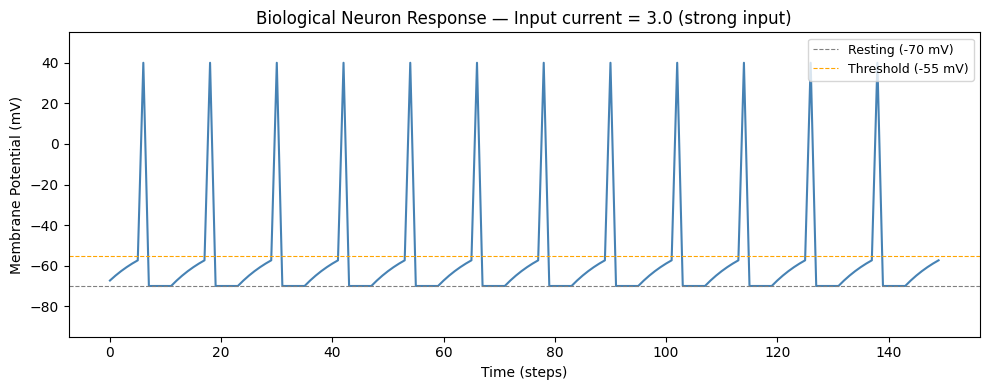

[-67.3,
 -64.86999999999999,
 -62.68299999999999,
 -60.71469999999999,
 -58.94322999999999,
 -57.348907,
 40,
 -70,
 -70,
 -70,
 -70,
 -70,
 -67.3,
 -64.86999999999999,
 -62.68299999999999,
 -60.71469999999999,
 -58.94322999999999,
 -57.348907,
 40,
 -70,
 -70,
 -70,
 -70,
 -70,
 -67.3,
 -64.86999999999999,
 -62.68299999999999,
 -60.71469999999999,
 -58.94322999999999,
 -57.348907,
 40,
 -70,
 -70,
 -70,
 -70,
 -70,
 -67.3,
 -64.86999999999999,
 -62.68299999999999,
 -60.71469999999999,
 -58.94322999999999,
 -57.348907,
 40,
 -70,
 -70,
 -70,
 -70,
 -70,
 -67.3,
 -64.86999999999999,
 -62.68299999999999,
 -60.71469999999999,
 -58.94322999999999,
 -57.348907,
 40,
 -70,
 -70,
 -70,
 -70,
 -70,
 -67.3,
 -64.86999999999999,
 -62.68299999999999,
 -60.71469999999999,
 -58.94322999999999,
 -57.348907,
 40,
 -70,
 -70,
 -70,
 -70,
 -70,
 -67.3,
 -64.86999999999999,
 -62.68299999999999,
 -60.71469999999999,
 -58.94322999999999,
 -57.348907,
 40,
 -70,
 -70,
 -70,
 -70,
 -70,
 -67.3,
 -64.8699999

In [ ]:
neuron.simulate_response(3.0, label="strong input")

---
## Part 2: Artificial Neuron Model

An artificial neuron computes a **weighted sum** of its inputs, adds a bias,
then applies an **activation function** to produce its output.

In [ ]:
class ArtificialNeuron:
    """Implements a single artificial neuron with selectable activation function."""

    ACTIVATION_FUNCTIONS = ['sigmoid', 'relu', 'tanh', 'step']

    def __init__(self, num_inputs, activation='sigmoid'):
        if activation not in self.ACTIVATION_FUNCTIONS:
            raise ValueError(f"activation must be one of {self.ACTIVATION_FUNCTIONS}")
        np.random.seed(42)                          # reproducibility
        self.weights    = np.random.randn(num_inputs) * 0.5
        self.bias       = 0.0
        self.activation = activation

    def _apply_activation(self, z):
        """Applies the chosen activation function to weighted sum z."""
        if self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-z))
        elif self.activation == 'relu':
            return np.maximum(0, z)
        elif self.activation == 'tanh':
            return np.tanh(z)
        elif self.activation == 'step':
            # Most analogous to the biological all-or-none principle
            return (z >= 0).astype(float)

    def activate(self, inputs):
        """
        Computes neuron output for a given input vector.

        Parameters
        ----------
        inputs : array-like, shape (num_inputs,)

        Returns
        -------
        float : neuron output after activation
        """
        inputs = np.asarray(inputs)
        weighted_sum = np.dot(self.weights, inputs) + self.bias
        return self._apply_activation(weighted_sum)

### 2a — Compare all four activation functions  
Each plot shows a different activation function across a range of weighted-sum values.

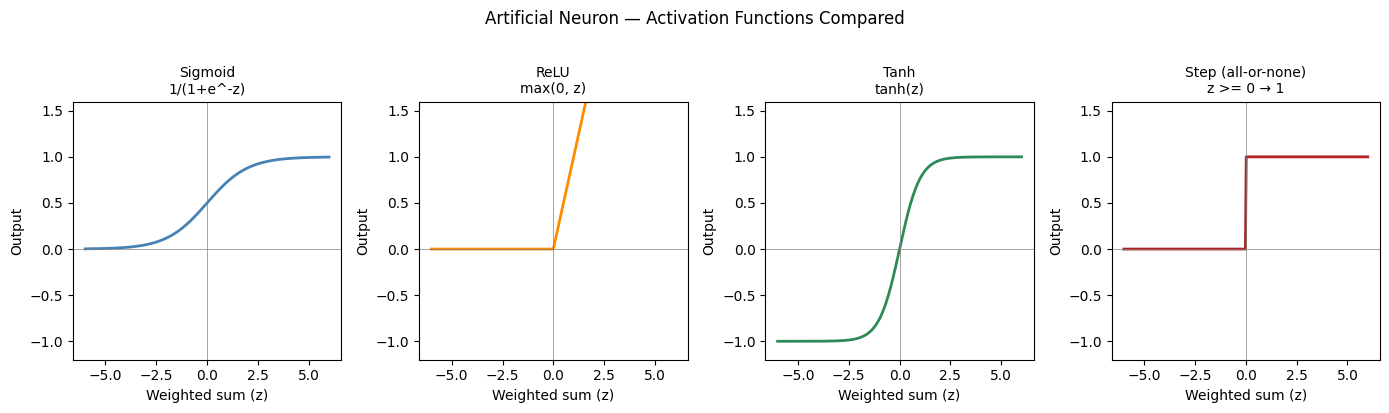

In [ ]:
z_values = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
configs = [
    ('sigmoid', 'steelblue',  'Sigmoid\n1/(1+e^-z)'),
    ('relu',    'darkorange', 'ReLU\nmax(0, z)'),
    ('tanh',    'seagreen',   'Tanh\ntanh(z)'),
    ('step',    'firebrick',  'Step (all-or-none)\nz >= 0 → 1'),
]

for ax, (name, color, title) in zip(axes, configs):
    neuron_tmp = ArtificialNeuron(num_inputs=1, activation=name)
    y_vals = [neuron_tmp._apply_activation(z) for z in z_values]
    ax.plot(z_values, y_vals, color=color, linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Weighted sum (z)")
    ax.set_ylabel("Output")
    ax.set_ylim(-1.2, 1.6)

plt.suptitle("Artificial Neuron — Activation Functions Compared", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 2b — Example: activate a neuron with 3 inputs

In [ ]:
inputs = np.array([0.5, 0.2, 0.8])

neuron_sig  = ArtificialNeuron(num_inputs=3, activation='sigmoid')
neuron_relu = ArtificialNeuron(num_inputs=3, activation='relu')

print("Sigmoid output:", round(neuron_sig.activate(inputs), 4))
print("ReLU output:   ", round(neuron_relu.activate(inputs), 4))

Sigmoid output: 0.5913
ReLU output:    0.3694


---
## Part 3: Simple Neural Network

A minimal **feedforward** network: 2 inputs → hidden layer → 1 output.  
This demonstrates how a network integrates information across multiple neurons.

In [ ]:
class SimpleNeuralNetwork:
    """
    Feedforward network: input layer → hidden layer → output neuron.
    Demonstrates information integration across multiple artificial neurons.
    """

    def __init__(self, num_inputs, num_hidden, activation='sigmoid'):
        np.random.seed(0)
        self.W1  = np.random.randn(num_hidden, num_inputs) * 0.5
        self.b1  = np.zeros(num_hidden)
        self.W2  = np.random.randn(num_hidden) * 0.5
        self.b2  = 0.0
        self.act = activation

    def _activate(self, z):
        if self.act == 'sigmoid':
            return 1 / (1 + np.exp(-z))
        elif self.act == 'relu':
            return np.maximum(0, z)
        return np.tanh(z)

    def forward(self, x):
        """Forward pass; returns (hidden activations, output)."""
        h   = self._activate(self.W1 @ x + self.b1)
        out = self._activate(np.dot(self.W2, h) + self.b2)
        return h, out

### 3a — Test all binary input combinations

In [ ]:
net = SimpleNeuralNetwork(num_inputs=2, num_hidden=3)

print("Network responses to binary input patterns:")
print(f"{'Input':>12} | {'Output':>8}")
print("-" * 25)
for x in [[0, 0], [0, 1], [1, 0], [1, 1]]:
    _, out = net.forward(np.array(x, dtype=float))
    print(f"  {str(x):>8}   |  {out:.4f}")

Network responses to binary input patterns:
       Input |   Output
-------------------------
    [0, 0]   |  0.5434
    [0, 1]   |  0.5460
    [1, 0]   |  0.5627
    [1, 1]   |  0.5647


### 3b — Visualise: output surface over continuous inputs

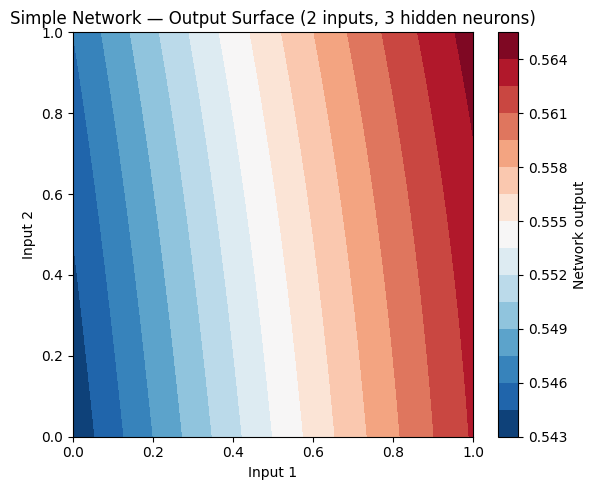

In [ ]:
x0_range = np.linspace(0, 1, 40)
x1_range = np.linspace(0, 1, 40)
Z = np.zeros((40, 40))

for i, x0 in enumerate(x0_range):
    for j, x1 in enumerate(x1_range):
        _, Z[j, i] = net.forward(np.array([x0, x1]))

fig, ax = plt.subplots(figsize=(6, 5))
cp = ax.contourf(x0_range, x1_range, Z, levels=20, cmap='RdBu_r')
plt.colorbar(cp, ax=ax, label='Network output')
ax.set_xlabel("Input 1")
ax.set_ylabel("Input 2")
ax.set_title("Simple Network — Output Surface (2 inputs, 3 hidden neurons)")
plt.tight_layout()
plt.show()